In [1]:
from langchain.llms import OpenAI
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import graphviz
from IPython.display import display, Image 
import re

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
load_dotenv()

# You can replace os.getenv('team_token') with a string containing the token, I just did it this way for more security
os.environ['OPENAI_API_KEY'] = os.getenv('team_token')

In [4]:
llm = OpenAI()

dsa_2214 = os.getenv('dsa_2214')

chapters = {
    'Chapter 1': 'Data Structures and Algorithms',
    'Chapter 2': 'Mathematical Preliminaries',
    'Chapter 3': 'Algorithm Analysis',
    'Chapter 4': 'Lists, Stacks, and Queues',
    'Chapter 5': 'Binary Trees',
    'Chapter 6': 'Non-Binary Trees',
    'Chapter 7': 'Internal Sorting',
    'Chapter 8': 'File Processing and External Sorting',
    'Chapter 9': 'Searching',
    'Chapter 10': 'Indexing',
    'Chapter 11': 'Graphs',
    'Chapter 12': 'Lists and Arrays Revisited',
    'Chapter 13': 'Advanced Tree Structures',
    'Chapter 14': 'Analysis Techniques',
    'Chapter 15': 'Lower Bounds',
    'Chapter 16': 'Patterns of Algorithms',
    'Chapter 17': 'Limits to Computation'
}

In [5]:
learning_concepts_list = []
learning_outcomes_list = []

for chapter, chapter_name in chapters.items():
    learning_concept = llm(f"Please identify the main learning concepts given {chapter}, the chapter name is {chapter_name}. Here is the textbook in which to retrieve them: {dsa_2214}")
    learning_concept = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', learning_concept)
    learning_concepts_list.append(learning_concept)

    learning_outcome = llm(f"Please identify the main learning outcomes given {chapter}, the chapter name is {chapter_name}. Here is the textbook in which to retrieve them: {dsa_2214}")
    learning_outcome = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', learning_outcome)
    learning_outcomes_list.append(learning_outcome)

KeyboardInterrupt: 

In [6]:
learning_concepts_list

['\n\n. Introduction to Data Structures and Algorithms\n. Basic Concepts of Data Structures\n. Abstract Data Types\n. Arrays and Linked Lists\n. Stacks and Queues\n. Recursion\n. Analysis of Algorithms\n. Sorting and Selection\n. Searching\n. Hash Tables\n. Trees\n. Binary Search Trees\n. AVL Trees\n. Heaps and Priority Queues\n. Graphs and Graph Traversals\n. Minimum Spanning Trees\n. Shortest Paths\n. String Matching Algorithms\n. BTrees and External Storage\n. Advanced Data Structures\n. Algorithm Design Techniques.',
 '\n\n. Number Systems The concept of different number systems, such as binary, octal, and hexadecimal, and their conversions to and from decimal numbers.\n\n. Arithmetic Operations Basic arithmetic operations, including addition, subtraction, multiplication, and division, and their properties and rules.\n\n. Order of Operations The concept of order of operations in mathematical expressions and how to evaluate them correctly.\n\n. Exponents and Logarithms The rules and

In [6]:
# Run 5 times and compare results, do this twice 

common_concepts_dict = {}
common_outcomes_dict = {}

for name in chapters.values():
    common_concepts_dict[name] = ([], [])
    common_outcomes_dict[name] = ([], [])

for i in range(2):
    for j in range(5):
        for chapter, chapter_name in chapters.items():
            learning_concept = llm(f"Please identify the main learning concepts given {chapter}, the chapter name is {chapter_name}. Here is the textbook in which to retrieve them: {dsa_2214}")
            learning_concept = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', learning_concept)
            print(learning_concept)
            common_concepts_dict[chapter_name][i].append([concept for concept in learning_concept.split('\n')[2:] if concept != ''])
    
            learning_outcome = llm(f"Please identify the main learning outcomes given {chapter}, the chapter name is {chapter_name}. Here is the textbook in which to retrieve them: {dsa_2214}")
            learning_outcome = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', learning_outcome)
            common_outcomes_dict[chapter_name][i].append([outcome for outcome in learning_outcome.split('\n')[2:] if outcome != ''])



. Introduction to data structures and algorithms
. Importance and applications of data structures and algorithms
. Basic data structures arrays, linked lists, stacks, queues, trees, and graphs
. Efficiency and complexity analysis of algorithms
. Algorithm design techniques brute force, divide and conquer, greedy algorithms, dynamic programming, and backtracking
. Sorting and searching algorithms
. Hashing and hash tables
. Recursion and recursive algorithms
. Trees and tree traversal algorithms
. Graphs and graph traversal algorithms
. Memory management and data representation
. Abstract data types and their implementation
. Analysis of common data structure operations insertion, deletion, search, and traversal
. Data structure design principles and best practices
. Introduction to algorithm analysis and design patterns.


. Basic mathematical operations Addition, subtraction, multiplication, division, and their properties.
. Number systems Natural numbers, integers, rational numbers,

In [8]:
common_concepts_dict

{'Data Structures and Algorithms': ([['. Introduction to Data Structures and Algorithms',
    '. Basic Data Structures Arrays, Lists, Stacks, Queues',
    '. Recursion and Recursive Algorithms',
    '. Algorithm Analysis and BigO Notation',
    '. Sorting Algorithms Bubble Sort, Selection Sort, Insertion Sort, Quick Sort, Merge Sort',
    '. Searching Algorithms Linear Search, Binary Search',
    '. Trees and Tree Algorithms Binary Trees, Binary Search Trees, AVL Trees',
    '. Hash Tables and Hashing Algorithms',
    '. Graphs and Graph Algorithms BreadthFirst Search, DepthFirst Search, Dijkstras Algorithm',
    '. Memory Management and Dynamic Data Structures',
    '. ObjectOriented Programming and Data Structures',
    '. Designing Efficient Algorithms',
    '. Divide and Conquer Algorithms',
    '. Greedy Algorithms',
    '. Dynamic Programming',
    '. NPCompleteness and Approximation Algorithms.'],
   ['. Introduction to Data Structures and Algorithms',
    '. Basic data structur

In [9]:
common_outcomes_dict

{'Data Structures and Algorithms': ([['. Understand the fundamental concepts of data structures and algorithms',
    '. Analyze and compare different data structures and their efficiency for specific tasks',
    '. Implement and manipulate data structures using the Java programming language',
    '. Understand the importance of algorithm efficiency and how to analyze and improve it',
    '. Learn different sorting algorithms and their complexities',
    '. Understand the concept of recursion and its applications in data structures and algorithms',
    '. Apply data structures and algorithms to solve realworld problems',
    '. Understand the tradeoffs between different data structures and algorithms',
    '. Learn how to design and implement abstract data types',
    '. Understand the concept of bigO notation and its applications in analyzing algorithm efficiency.'],
   ['. Understand the basic concepts of data structures and algorithms',
    '. Recognize the importance of choosing app

In [7]:
in_common_concepts = {}
in_common_outcomes = {}

for key in chapters.values():
    in_common_concepts[key] = []
    in_common_outcomes[key] = []

first_key = list(common_concepts_dict.keys())[0]

for idx in range(len(common_concepts_dict[first_key])):
    for chapter_name, chapter_concepts in common_concepts_dict.items():
        content = llm(f"Please identify the common concepts between these lists of concepts for chapter {chapter_name}? {chapter_concepts[idx][0]}, {chapter_concepts[idx][1]}, {chapter_concepts[idx][2]}, {chapter_concepts[idx][3]}, {chapter_concepts[idx][4]}? Please limit your response to 20 concepts in a list format.")
        in_common_concepts[chapter_name].append(content.split('\n')[2:])
    
    for chapter_name, chapter_outcomes in common_outcomes_dict.items():
        content = llm(f"Please identify the common learning outcomes between these lists for chapter {chapter_name}? {chapter_outcomes[idx][0]}, {chapter_outcomes[idx][1]}, {chapter_outcomes[idx][2]}, {chapter_outcomes[idx][3]}, {chapter_outcomes[idx][4]}? Please limit your response to 20 outcomes in a list format.")
        in_common_outcomes[chapter_name].append(content.split('\n')[2:])


In [11]:
in_common_concepts

{'Data Structures and Algorithms': [['- Introduction to Data Structures and Algorithms',
   '- Basic Terminology and Definitions',
   '- Complexity Analysis',
   '- Arrays, Linked Lists, Stacks, and Queues',
   '- Trees and Tree Traversal',
   '- Binary Search Trees and Balanced Trees',
   '- Hash Tables',
   '- Priority Queues and Heaps',
   '- Sorting and Selection',
   '- Graphs and Graph Traversal',
   '- Algorithm Design Techniques',
   '- Greedy Algorithms, Dynamic Programming, Backtracking, Divide and Conquer',
   '- String Matching',
   '- NPCompleteness',
   '- Fundamental Algorithms and Their Analysis',
   '- Abstract Data Types',
   '- Object-Oriented Programming and Design Patterns in Data Structures and Algorithms',
   '- Efficiency and BigO Notation',
   '- Fundamental Data Structures (Arrays, Linked Lists, Stacks, Queues)',
   '- Recursion',
   '- Sorting Algorithms and Their Analysis',
   '- Searching Algorithms and Their Analysis',
   '- Advanced Data Structures (Trees

In [12]:
in_common_outcomes

{'Data Structures and Algorithms': [['The common learning outcomes between these lists for chapter Data Structures and Algorithms include:',
   '',
   '- Understanding the fundamental concepts of data structures and algorithms',
   '- Analyzing and comparing different data structures and their efficiency for specific tasks',
   '- Implementing and manipulating data structures using the Java programming language',
   '- Understanding the importance of algorithm efficiency and how to analyze and improve it',
   '- Learning different sorting algorithms and their complexities',
   '- Understanding the concept of recursion and its applications in data structures and algorithms',
   '- Applying data structures and algorithms to solve real-world problems',
   '- Understanding the trade-offs between different data structures and algorithms',
   '- Learning how to design and implement abstract data types',
   '- Understanding the concept of bigO notation and its applications in analyzing algori

In [8]:
final_common_concept_dict = {}
final_common_outcome_dict = {}

for key in in_common_concepts.keys():
    content = llm(f"Please identify the common concepts between these two lists: {in_common_concepts[key][0]}, {in_common_concepts[key][1]}")
    final_common_concept_dict[key] = [concept for concept in content.split('\n')[2:] if concept.strip() != '']

    content = llm(f"Please identify the common learning outcomes between these two lists: {in_common_outcomes[key][0]}, {in_common_outcomes[key][1]}")
    final_common_outcome_dict[key] = [outcome for outcome in content.split('\n')[2:] if outcome.strip() != '']


In [8]:
final_common_concept_dict

{'Data Structures and Algorithms': ['1. Basic concepts and definitions',
  '2. Complexity analysis',
  '3. Notation (bigO, bigomega, bigtheta)',
  '4. Growth of functions',
  '5. Recursion',
  '6. Arrays',
  '7. Linked lists',
  '8. Stacks',
  '9. Queues',
  '10. Trees',
  '11. Searching algorithms',
  '12. Sorting algorithms',
  '13. Graphs'],
 'Mathematical Preliminaries': ['1. Set theory and operations',
  '2. Number systems and their properties',
  '3. Basic algebraic expressions and equations',
  '4. Order of operations',
  '5. Exponents and logarithms',
  '6. Functions and their properties',
  '7. Sequences and series',
  '8. Modular arithmetic',
  '9. Representation of numbers',
  '10. Arithmetic operations',
  '11. Logarithms',
  '12. Set theory',
  '13. Set operations',
  '14. Functions',
  '15. Solving equations',
  '16. Sequences',
  '17. Series',
  '18. Modular arithmetic',
  '19. Real numbers',
  '20. Complex numbers'],
 'Algorithm Analysis': ['1. Time complexity analysis'

In [9]:
import warnings
warnings.filterwarnings('ignore')

keys = list(final_common_concept_dict.keys())
dependencies = {}

for key in keys:
    dependencies[key] = []

for i in range(len(keys)):
    current_concept = final_common_concept_dict[keys[i]]
    for j in range(i + 1, len(keys)):
        next_concept = final_common_concept_dict[keys[j]]
        content = llm(f"Please identify if this list of concepts: {next_concept} has a prerequisite for this list of concepts: {current_concept}. If there is NO prerequisite, please respond with 'No' and 'No' only.")
        print(content)
        if content.split(',')[0].strip() != 'No':
            dependencies[keys[j]].append(keys[i])
dependencies



No


No


No


No


No


No


No


Yes


Yes


No


No


No


Yes


Yes, the prerequisite for this list of concepts is 'Performance analysis'.


No


Yes, there is a prerequisite.


No


No


No


No


No


Yes


No


No


No


No


No


Yes


No


No


No


No


Yes


Yes


Yes, there is a prerequisite for this list of concepts. The prerequisite is 'Efficiency and complexity analysis' and 'Analysis of recursive algorithms'.


Yes


Yes


Yes, this list of concepts does have a prerequisite for the list of concepts provided. The prerequisite is likely a strong understanding of complexity analysis, algorithm design techniques, and analysis of sorting and searching algorithms.


No


Yes


No


Yes

No


Yes, the list of concepts has a prerequisite for the list of concepts.


No

No, there is no prerequisite for this list of concepts.


Yes, there is a prerequisite for this list of concepts: ['1. Lists', '2. Stacks', '3. Queues', '4. Data structure', '5. Linked lists', '6. Array-based l

{'Data Structures and Algorithms': [],
 'Mathematical Preliminaries': [],
 'Algorithm Analysis': [],
 'Lists, Stacks, and Queues': [],
 'Binary Trees': ['Algorithm Analysis'],
 'Non-Binary Trees': ['Algorithm Analysis', 'Lists, Stacks, and Queues'],
 'Internal Sorting': ['Algorithm Analysis'],
 'File Processing and External Sorting': ['Mathematical Preliminaries',
  'Algorithm Analysis'],
 'Searching': ['Data Structures and Algorithms',
  'Algorithm Analysis',
  'Binary Trees'],
 'Indexing': ['Data Structures and Algorithms',
  'Algorithm Analysis',
  'Internal Sorting'],
 'Graphs': ['Binary Trees', 'Internal Sorting'],
 'Lists and Arrays Revisited': ['Algorithm Analysis',
  'Lists, Stacks, and Queues',
  'Binary Trees',
  'Searching'],
 'Advanced Tree Structures': ['Indexing'],
 'Analysis Techniques': ['Data Structures and Algorithms',
  'Mathematical Preliminaries',
  'Algorithm Analysis',
  'Internal Sorting',
  'Indexing',
  'Graphs',
  'Lists and Arrays Revisited',
  'Advanced Tre

In [10]:
import graphlib
sorted_dependencies = graphlib.TopologicalSorter(graph = dependencies)
sorted_dependencies = tuple(sorted_dependencies.static_order())
print(sorted_dependencies)

# sorted_dependencies = {k:v for k, v in zip(sorted_dependencies, dependencies.values())}
# print(sorted_dependencies)

('Data Structures and Algorithms', 'Mathematical Preliminaries', 'Algorithm Analysis', 'Lists, Stacks, and Queues', 'Binary Trees', 'Internal Sorting', 'File Processing and External Sorting', 'Non-Binary Trees', 'Searching', 'Indexing', 'Graphs', 'Lists and Arrays Revisited', 'Advanced Tree Structures', 'Patterns of Algorithms', 'Analysis Techniques', 'Lower Bounds', 'Limits to Computation')


/home/zhutchens/uncc/research/LLM/my_work/venv/lib/python3.10/site-packages/hypernetx/classes/entityset.py:150: DeprecationWarning: misc_props_col and misc_cell_props_col will be deprecated; all public references to these arguments will be removed in a future release.
  warnings.warn(
/home/zhutchens/uncc/research/LLM/my_work/venv/lib/python3.10/site-packages/hypernetx/classes/hypergraph.py:563: FutureWarning: This method or function will be deprecated in a future release. Public references to this method or function will be removed from the Hypergraph API in a future release.
  self._nodes = self.E.restrict_to_levels([1])
/home/zhutchens/uncc/research/LLM/my_work/venv/lib/python3.10/site-packages/hypernetx/classes/entityset.py:618: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  elements = self._da

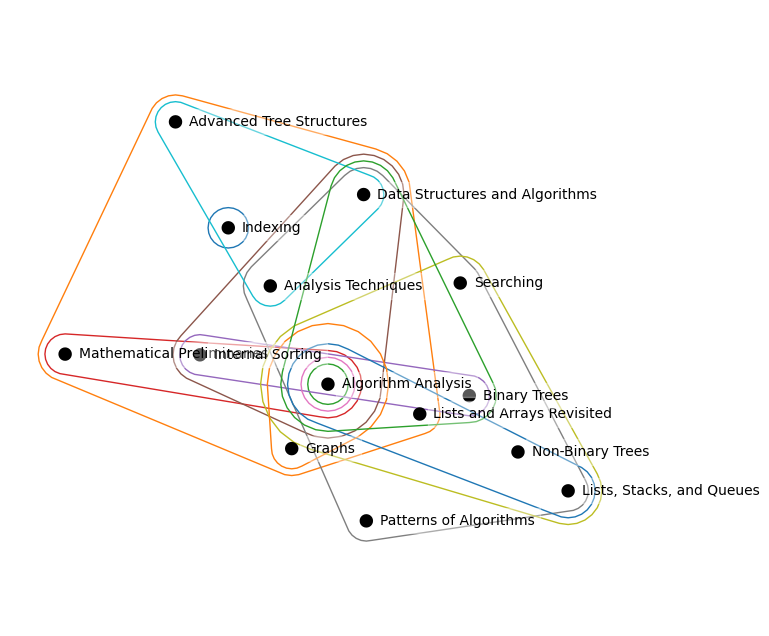

In [11]:
from hypernetx import draw, Hypergraph

temp = sorted_dependencies
sorted_dependencies = {}

for value in temp:
    sorted_dependencies[value] = dependencies[value]

draw(Hypergraph(sorted_dependencies), with_edge_labels = False, with_node_labels = True)

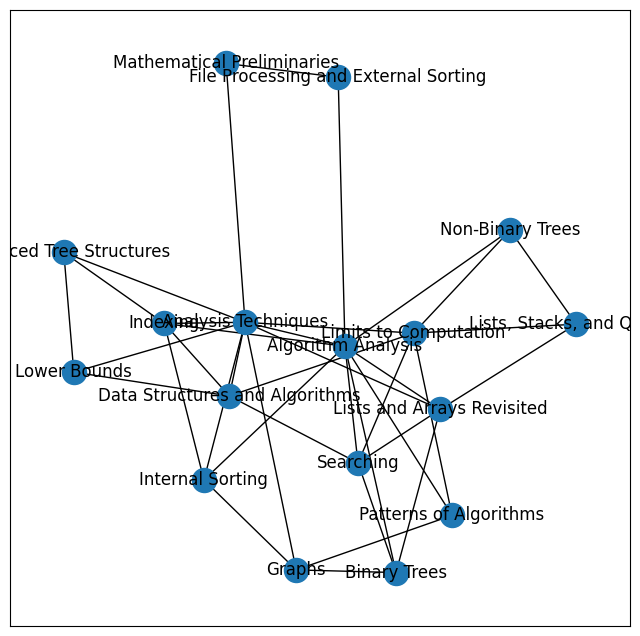

In [12]:
import multinetx as mx 
mg = mx.MultilayerGraph()

for node, edges in sorted_dependencies.items():
    mg.add_node(node_for_adding = node)
    for edge in edges:
        mg.add_edge(u_of_edge = node, v_of_edge = edge)

mx.draw_networkx(G = mg)
plt.show()

In [ ]:
# Create learning concept graph association structure
learning_concept_graph = {}
for idx, name in enumerate(chapters.values()):
    learning_concept_graph[name] = (learning_concepts_list[idx], learning_outcomes_list[idx])

# Dictionary structure now:
# The key is the chapter title, and the value is a tuple containing the learning concept(s) at index 0, and outcome(s) at index 1
learning_concept_graph

In [ ]:
association_dict = {}

for name in chapters.values():
    association_dict[name] = []

# Build associations algorithm
for i in range(len(list(learning_concept_graph.values()))):
    current_tuple = list(learning_concept_graph.values())[i]
    for j in range(i + 1, len(list(learning_concept_graph.values()))):
        next_tuple = list(learning_concept_graph.values())[j]
        print(f"Current concept: {current_tuple[0]}, next concept: {next_tuple[0]}")
        new_association = llm(f"Please identify if there is an association between this concept: {current_tuple[0]}, and this other concept: {next_tuple[0]}. If there is NO association, please start your response with 'No' and 'No' only.")
        new_association = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', new_association)
        # Try to only add associations to the graph, but its difficult because sometimes the LLM won't start its response with 'No'
        if new_association.split(',')[0].strip() != 'No':
            association_dict[list(learning_concept_graph.keys())[i]].append(list(learning_concept_graph.keys())[j])


In [ ]:
association_dict

In [ ]:
graph = graphviz.Digraph(name = "Learning Concept Associations")

for key, values in association_dict.items():
    graph.node(name = key)
    for value in values:
        graph.edge(key, value)

display(Image(graph.pipe(format = "png", renderer = "cairo")))

In [ ]:
from pyvis.network import Network

graph = Network(notebook = True, cdn_resources = "remote")

graph.toggle_physics(False)

# Showing all interactivity options, but can be parameterized to only include some
graph.show_buttons()

node_id_dict = {}
count = 1
for name in list(learning_concept_graph.keys()):
    node_id_dict[name] = count
    count += 1

for chapter_name, chapter_id in node_id_dict.items():
    graph.add_node(n_id = chapter_id, label = chapter_name, title = "Main Learning Concepts: " + learning_concept_graph[chapter_name][0] + "\n" + "Main Learning Outcomes:" + learning_concept_graph[chapter_name][1])

for key, values in association_dict.items():
    for value in values:
        graph.add_edge(node_id_dict[key], node_id_dict[value])

graph.show(name = "interactive.html")

In [ ]:
topics = llm(f"Can you give 10 main topics from this textbook? {dsa_2214}")
topics = topics.split('\n')
for topic in topics:
    print(topic)

In [ ]:
main_concept_graph = {}

for topic in topics[2:]:
    main_concept_graph[topic] = []
main_concept_graph.keys()

In [ ]:
for i in range(2, len(topics)):
    for j in range(2, len(topics)):
        if i != j:
            association = llm(f'Are there any associations between {topics[i]} and {topics[j]}? If there are NOT, please respond with "No" and "No" only.')
            association = re.sub(re.compile('[^a-zA-Z\s\.,!?]',), '', association)
            if association.split()[0] != 'No':
                main_concept_graph[topics[i]].append(topics[j])

In [ ]:
main_graph = graphviz.Digraph(name = "Main Concept Graph")

for key in main_concept_graph.keys():
    main_graph.node(name = key)

for key, values in main_concept_graph.items():
    for value in values:
        main_graph.edge(key, value)

display(Image(main_graph.pipe(format = "png", renderer = "cairo")))

Task 3 Subtask 1


In [ ]:
i = 1
for key, value in learning_concept_graph.items():
    print(f'CHAPTER: {i}')
    print(key)
    print('') # just for a cleaner output
    i += 1


In [ ]:
relations = {}
keys = list(learning_concept_graph.keys())
values = list(learning_concept_graph.values())

for key in keys:
    relations[key] = []

def check_feedback_loop(relation_dict: dict, starting: str, ending: str) -> bool:
    if starting == ending:
        return True
    else:
        visited_concepts = []
        tracking_lst = [starting]
        while tracking_lst:
            current_concept = tracking_lst.pop()
            if current_concept == ending:
                return True
            visited_concepts.append(current_concept)
            tracking_lst = [concept for concept in relation_dict.get(current_concept) if concept not in visited_concepts]
        return False


# Should this not be the other way around? It doesnt make sense to start at chapter 1 and ask if it depends on other chapters
# for i in range(len(values)):
#     current_tuple = values[i]
#     for j in range(i + 1, len(values)):
        
#         next_tuple = values[j]
        
#         new_dependency = llm(f"Please identify if this concept: {current_tuple[0]} has a dependency for this concept: {next_tuple[0]}. If there is NO dependency, please start your response with 'No' and 'No' only.")
#         new_dependency = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', new_dependency)
        
#         # Try to only add associations to the graph, but its difficult because sometimes the LLM won't start its response with 'No'
#         if new_dependency.split(',')[0].strip() != 'No' and not check_feedback_loop(relations, keys[j], keys[i]):
#             relations[keys[i]].append(keys[j])


# loop the other way 
# for i in range(len(values) - 1, -1, -1):
#     for j in range(i - 1, -1, -1):
#         current_tuple = values[i]
#         next_tuple = values[j]
        
#         new_dependency = llm(f"Please identify if this concept: {current_tuple[0]} has a dependency for this concept: {next_tuple[0]}. If there is NO dependency, please start your response with 'No' and 'No' only.")
#         print(new_dependency)
#         new_dependency = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', new_dependency)
        
#         # Try to only add associations to the graph, but its difficult because sometimes the LLM won't start its response with 'No'
#         if new_dependency.split(',')[0].strip() != 'No' and not check_feedback_loop(relations, keys[j], keys[i]):
#             relations[keys[i]].append(keys[j])
# relations

# Run 10 times and compare graphs
for i in range(10):
    
    relations = {}
    keys = list(learning_concept_graph.keys())
    values = list(learning_concept_graph.values())

    for key in keys:
        relations[key] = []
    
    for i in range(len(values) - 1, -1, -1):
        for j in range(i - 1, -1, -1):
            current_tuple = values[i]
            next_tuple = values[j]
            
            new_dependency = llm(f"Please identify if this concept: {current_tuple[0]} has a prerequisite for this concept: {next_tuple[0]}. If there is NO dependency, please start your response with 'No' and 'No' only.")
            new_dependency = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', new_dependency)
            
            # Try to only add associations to the graph, but its difficult because sometimes the LLM won't start its response with 'No'
            if new_dependency.split(',')[0].strip() != 'No' and not check_feedback_loop(relations, keys[j], keys[i]):
                relations[keys[i]].append(keys[j])

    directed_graph = graphviz.Digraph()

    for key, values in relations.items():
        directed_graph.node(name = key)
        for value in values:
            directed_graph.edge(key, value)

    display(Image(directed_graph.pipe(format = "png", renderer = "cairo")))

Task 3 Subtask 2

In [ ]:
directed_graph = graphviz.Digraph()

for key, values in relations.items():
    directed_graph.node(name = key)
    for value in values:
        directed_graph.edge(key, value)

display(Image(directed_graph.pipe(format = "png", renderer = "cairo")))